In [87]:
import pandas as pd

# Load the CSV file
df = pd.read_csv("crafted_dataset_10k.csv")
print(df.head())

                                            sentence  \
0              need {route_length: 800 meters} track   
1  {start_location: near me} to {end_location: me...   
2  I'm staying at {start_location: shimshon} {loc...   
3  Plan a route from {start_location: king george...   
4  run from {start_location: acre} to {end_locati...   

                                              tokens  \
0                           need, 800, meters, track   
1  near, me, to, meah, shearim, street, 40, ,, no...   
2  I'm, staying, at, shimshon, 11, and, would, lo...   
3  Plan, a, route, from, king, george, street, 9,...   
4                   run, from, acre, to, hapisga, 16   

                                            bio_tags  
0               O, B-route_length, I-route_length, O  
1  B-start_location, I-start_location, O, B-end_l...  
2  O, O, O, B-start_location, B-loca_start_num, O...  
3  O, O, O, O, B-start_location, I-start_location...  
4  O, O, B-start_location, O, B-end_location, B-l..

In [88]:
# Split 'tokens' and 'bio_tags' columns into lists
df['tokens'] = df['tokens'].apply(lambda x: x.split(', '))
df['bio_tags'] = df['bio_tags'].apply(lambda x: x.split(', '))

# Check the updated dataframe
print(df[['tokens', 'bio_tags']].head())

                                              tokens  \
0                         [need, 800, meters, track]   
1  [near, me, to, meah, shearim, street, 40, ,, n...   
2  [I'm, staying, at, shimshon, 11, and, would, l...   
3  [Plan, a, route, from, king, george, street, 9...   
4                 [run, from, acre, to, hapisga, 16]   

                                            bio_tags  
0             [O, B-route_length, I-route_length, O]  
1  [B-start_location, I-start_location, O, B-end_...  
2  [O, O, O, B-start_location, B-loca_start_num, ...  
3  [O, O, O, O, B-start_location, I-start_locatio...  
4  [O, O, B-start_location, O, B-end_location, B-...  


In [31]:
!pip install nltk

In [89]:
import nltk
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [93]:
# this is the second option
import pandas as pd
import numpy as np
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import string
pd.set_option('display.max_colwidth', None)

# Initialize lemmatizer and stopwords
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

# Text Preprocessing Function
def preprocess_text(tokens):
    # Lowercase and remove punctuation for each token
    tokens = [token.lower() for token in tokens]
    tokens = [token for token in tokens if token not in string.punctuation]

    # # Remove "km" and "kilometers"
    # tokens = [token for token in tokens if token not in ['km', 'kilometers']]

    # Replace integers and floats with <DIG>
    tokens = ['<DIG>' if token.replace('.', '', 1).isdigit() else token for token in tokens]

    # Lemmatize and remove stopwords, but keep <DIG>
    tokens = [lemmatizer.lemmatize(token) for token in tokens if token not in stop_words or token == '<DIG>']

    return tokens

# Apply preprocessing to the tokens
df['tokens'] = df['tokens'].apply(lambda x: preprocess_text(x))
# Get unique words and tags
words = list(set([word for sentence in df['tokens'] for word in sentence]))
tags = list(set([tag for tag_seq in df['bio_tags'] for tag in tag_seq]))

# Add an "UNK" token to handle unknown words
words.append('UNK')

# Create word and tag dictionaries
word2idx = {w: i + 1 for i, w in enumerate(words)}  # Indexing starts from 1
tag2idx = {t: i for i, t in enumerate(tags)}

# Create reverse mapping for tags
idx2tag = {i: t for t, i in tag2idx.items()}

# Convert tokens and tags to indices
X = [[word2idx.get(word, word2idx['UNK']) for word in sentence] for sentence in df['tokens']]
y = [[tag2idx[tag] for tag in tag_seq] for tag_seq in df['bio_tags']]

# Pad sequences to ensure uniform input lengths
max_len = 50  # Choose an appropriate max length based on your data
X_pad = pad_sequences(X, maxlen=max_len, padding='post')
y_pad = pad_sequences(y, maxlen=max_len, padding='post')

# One-hot encode the BIO-tags
y_one_hot = [to_categorical(tag_seq, num_classes=len(tag2idx)) for tag_seq in y_pad]

# Convert to numpy arrays
X_pad = np.array(X_pad)
y_one_hot = np.array(y_one_hot)

# Check the shape of the preprocessed data
print(f"X_pad shape: {X_pad.shape}")
print(f"y_one_hot shape: {y_one_hot.shape}")


0                                                            [need, <dig>, meter, track]
1                                        [near, meah, shearim, street, <dig>, difficult]
2    [i'm, staying, shimshon, <dig>, would, love, somewhat, tough, route, explore, city]
Name: tokens, dtype: object
0                                                                                                     need {route_length: 800 meters} track
1                                    {start_location: near me} to {end_location: meah shearim street} {loca_end_num: 40}, not too difficult
2    I'm staying at {start_location: shimshon} {loca_start_num: 11} and would love a {difficulty: somewhat tough} route to explore the city
Name: sentence, dtype: object
0                                                            [need, <dig>, meter, track]
1                                        [near, meah, shearim, street, <dig>, difficult]
2    [i'm, staying, shimshon, <dig>, would, love, somewhat, tough, route, exp

In [78]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X_pad, y_one_hot, test_size=0.2, random_state=42) #in the final state we should remove random_state

# Check the shape of the split data
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")


X_train shape: (8000, 50)
X_test shape: (2000, 50)
y_train shape: (8000, 50, 11)
y_test shape: (2000, 50, 11)


In [79]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, LSTM, Bidirectional, Dense, TimeDistributed, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam

# Build the model
model = Sequential()

# Explicitly add Input layer
model.add(Input(shape=(X_train.shape[1],)))

# Embedding layer
model.add(Embedding(input_dim=len(word2idx) + 1, output_dim=100))  # Increased embedding dimension

# BiLSTM layer with more units
model.add(Bidirectional(LSTM(units=200, return_sequences=True, dropout=0.2, recurrent_dropout=0.2)))  # Increased LSTM units

# Dropout layer for regularization
model.add(Dropout(0.2))

# BatchNormalization layer
model.add(BatchNormalization())

# TimeDistributed Dense layer for token classification
model.add(TimeDistributed(Dense(len(tag2idx), activation='softmax')))

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

# Summarize the model
model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_7 (Embedding)              │ (None, 50, 100)             │          92,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_7 (Bidirectional)      │ (None, 50, 400)             │         481,600 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 50, 400)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 50, 400)             │           1,600 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ time_distributed_7 (TimeDistributed) │ (None, 50, 11)              │           4,411 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 580,411 (2.21 MB)

 Trainable params: 579,611 (2.21 MB)

 Non-trainable params: 800 (3.12 KB)

In [80]:
# Set batch size and number of epochs
batch_size = 32
epochs = 20

# Train the model
history = model.fit(
    X_train, y_train,
    validation_split=0.2,  # Use 20% of the training data as validation data
    batch_size=batch_size,
    epochs=epochs,
    verbose=1
)
print("")
print("")
print("DONE!")

Epoch 1/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 82s 369ms/step - accuracy: 0.8356 - loss: 0.7297 - val_accuracy: 0.8790 - val_loss: 0.7980
Epoch 2/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 80s 360ms/step - accuracy: 0.9057 - loss: 0.2933 - val_accuracy: 0.8790 - val_loss: 0.3755
Epoch 3/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 75s 328ms/step - accuracy: 0.9132 - loss: 0.2394 - val_accuracy: 0.9148 - val_loss: 0.2218
Epoch 4/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 82s 329ms/step - accuracy: 0.9214 - loss: 0.2076 - val_accuracy: 0.9311 - val_loss: 0.1760
Epoch 5/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 82s 331ms/step - accuracy: 0.9315 - loss: 0.1797 - val_accuracy: 0.9408 - val_loss: 0.1561
Epoch 6/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 82s 332ms/step - accuracy: 0.9358 - loss: 0.1665 - val_accuracy: 0.9470 - val_loss: 0.1388
Epoch 7/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 66s 327ms/step - accuracy: 0.9410 - loss: 0.1522 - val_accuracy: 0.9519 - val_loss: 0.1262
Epoch 8/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 82s 327ms/step - accuracy: 0.9487 - loss: 0

In [81]:
# Evaluate on the test set
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")


63/63 ━━━━━━━━━━━━━━━━━━━━ 8s 104ms/step - accuracy: 0.9700 - loss: 0.0863
Test Loss: 0.0819
Test Accuracy: 0.9709


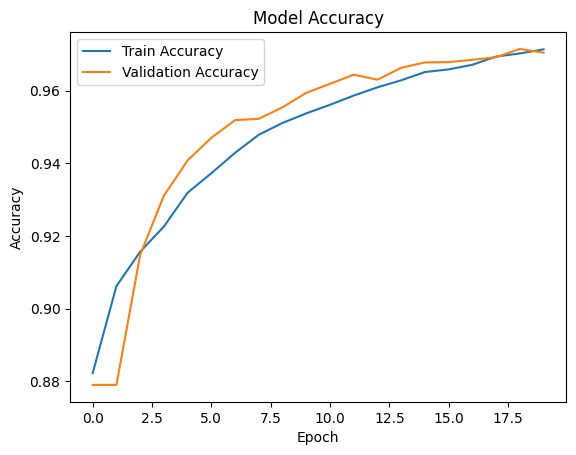

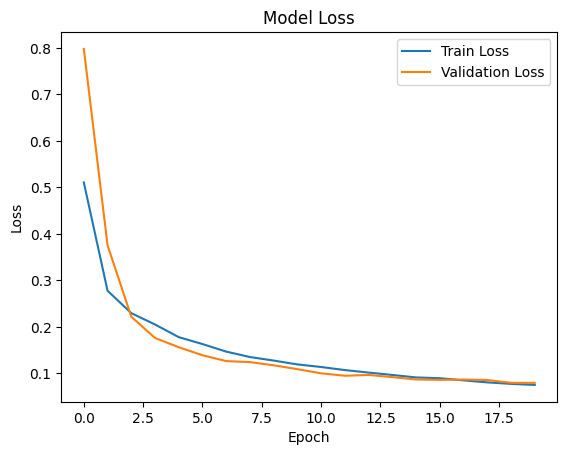

In [82]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Plot training & validation loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


In [85]:
# this is the second option
# Custom sentence for testing
custom_sentence = "need simple very easy route 14.0 kilometers from dan shechtman 19 to herzl street 60"
#custom_sentence = "i want to run a 6 km mediocure difficulty route from haddase 8 to harimon 99"

custom_tokens = preprocess_text(custom_sentence.split())

# Tokenize the sentence (ensure unknown words get a proper index, "UNK" for unknown words)
custom_tokens = [word2idx.get(word, word2idx.get("UNK", 0)) for word in custom_tokens]

# Pad the sequence
custom_padded = pad_sequences([custom_tokens], maxlen=X_train.shape[1], padding='post', truncating='post')

# Predict tags
predicted_probs = model.predict(custom_padded)
predicted_indices = np.argmax(predicted_probs, axis=-1).flatten()

# Map indices to tags
predicted_tags = [idx2tag.get(index, "O") for index in predicted_indices]  # Default to "O" if the index isn't found

# Combine tokens and tags
decoded_output = list(zip(custom_sentence.split(), predicted_tags[:len(custom_sentence.split())]))

# Display the result
print("Word - Predicted Tag")
for word, tag in decoded_output:
    print(f"{word} - {tag}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Word - Predicted Tag
need - O
simple - O
very - B-difficulty
easy - I-difficulty
route - O
14.0 - B-route_length
kilometers - I-route_length
from - O
dan - B-start_location
shechtman - I-start_location
19 - B-loca_start_num
to - O
herzl - B-end_location
street - I-end_location
60 - B-loca_end_num


In [ ]:
#if we run this we should celebrate :)

#model.save("bilstm_bio_tagging_model.h5")